<a href="https://colab.research.google.com/github/shahzebather-ui/Text-analytics-assignment2/blob/main/Assingment_2_(Text_Mining).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# Feature engineering
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Train/eval
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv("/content/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
# @title
print(f"Shape:\n", df.shape)
print("")
print(f"D-types:\n",df.dtypes)
print("")
print(f"Missing Values:",df.isna().sum().sum())
print("")
print(df['sentiment'].value_counts())
print("")
print(f"Duplicates:\n", df.duplicated().sum())

#print(df['review'].value_counts())

Shape:
 (50000, 2)

D-types:
 review       object
sentiment    object
dtype: object

Missing Values: 0

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Duplicates:
 418


In [9]:
df = df.drop_duplicates()
print(df.shape)

(49582, 2)


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
#Text length stats per class
df['review_length'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()
print(df.groupby('sentiment')[['review_length', 'word_count']].describe())

          review_length                                                \
                  count         mean          std   min    25%    50%   
sentiment                                                               
negative        24698.0  1294.739615   946.501793  32.0  706.0  974.0   
positive        24884.0  1326.278532  1032.597204  65.0  692.0  969.0   

                            word_count                                       \
               75%      max      count        mean         std   min    25%   
sentiment                                                                     
negative   1568.00   8969.0    24698.0  229.596607  165.103430   4.0  128.0   
positive   1615.25  13704.0    24884.0  233.090620  177.688169  10.0  125.0   

                                 
             50%    75%     max  
sentiment                        
negative   174.0  278.0  1522.0  
positive   172.0  284.0  2470.0  


In [12]:
df['word_count'] = df['review'].str.split().str.len()
print(df.groupby('sentiment')['word_count'].mean())

sentiment
negative    229.596607
positive    233.090620
Name: word_count, dtype: float64


In [13]:
#Empty/whitespace-only reviews
print(f"Empty reviews: {(df['review'].str.strip() == '').sum()}")

Empty reviews: 0


In [14]:
#Encode label (you'll need this for modeling) df['label'] = (df['sentiment'] == 'positive').astype(int)
df['label'] = (df['sentiment'] == 'positive').astype(int)
print(df[['sentiment', 'label']].head())

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1


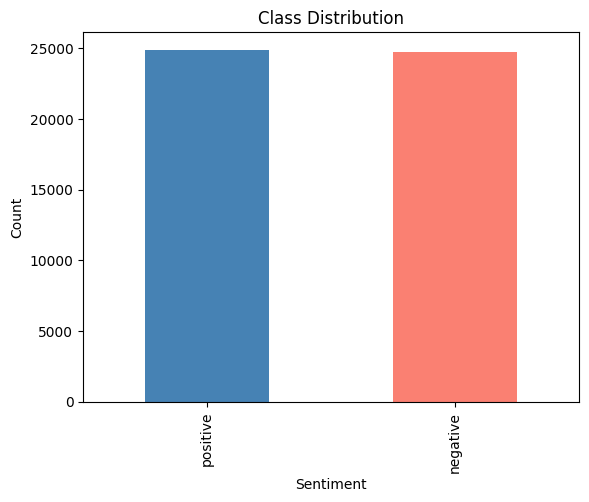

In [15]:
df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

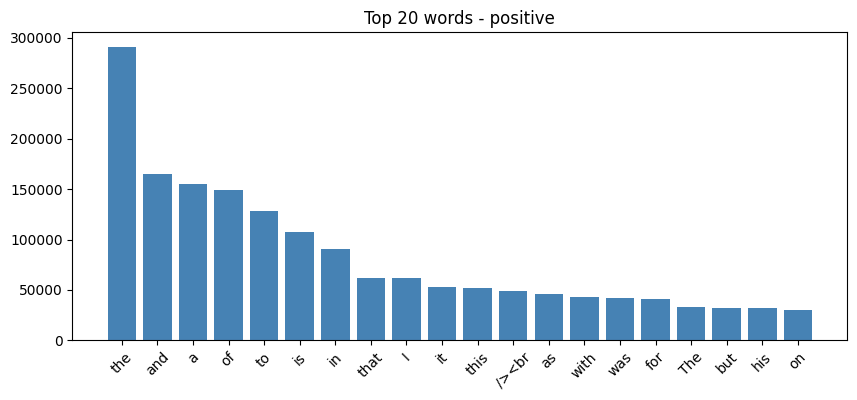

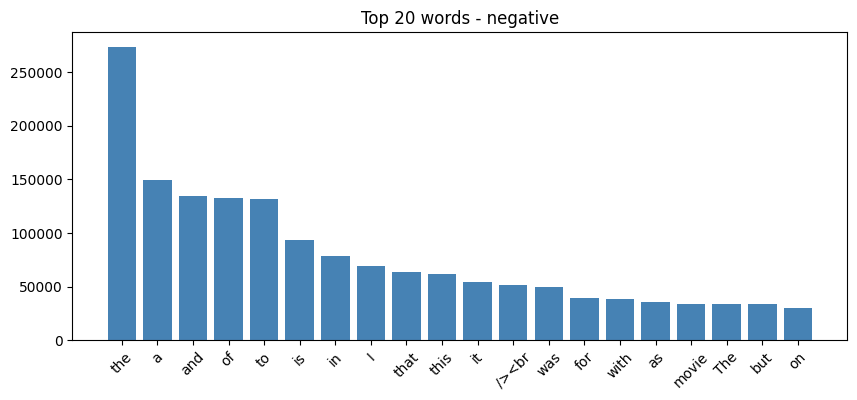

In [16]:
from collections import Counter

for sentiment in ['positive', 'negative']:
    words = ' '.join(df[df['sentiment'] == sentiment]['review']).split()
    common = Counter(words).most_common(20)
    words_only = [w[0] for w in common]
    counts_only = [w[1] for w in common]

    plt.figure(figsize=(10,4))
    plt.bar(words_only, counts_only, color='steelblue')
    plt.title(f'Top 20 words - {sentiment}')
    plt.xticks(rotation=45)
    plt.show()

In [20]:
#Remove HTML tags
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)    # remove HTML
    text = text.lower()                   # lowercase
    return text

df['clean'] = df['review'].apply(clean_text)

In [29]:
#Before and After Examples

print("BEFORE:", df['review'][1])
print("AFTER: ", df['cleaned_review'][1])
print()
print("BEFORE:", df['review'][3])
print("AFTER: ", df['cleaned_review'][3])
print()
print("BEFORE:", df['review'][10])
print("AFTER: ", df['cleaned_review'][10])

BEFORE: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well